# 02. Feature Engineering — RFM

**목표:** 고객별 RFM(Recency, Frequency, Monetary) 피처 생성 → 점수화 → 세그먼트 레이블 부여  
**이전:** `01_eda.ipynb` → `data/processed/retail_clean.parquet`  
**다음:** `03_modeling.ipynb` (K-Means 세그멘테이션 + 이탈 예측)

## 0. Setup

In [1]:
import sys
sys.path.append("../../")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from shared.plot_config import set_style
set_style()

PROCESSED_PATH = "../data/processed/retail_clean.parquet"
RFM_PATH = "../data/processed/rfm.parquet"

## 1. 데이터 로딩

In [2]:
df = pd.read_parquet(PROCESSED_PATH)
print(f"Shape: {df.shape}")
print(f"기간: {df['InvoiceDate'].min().date()} ~ {df['InvoiceDate'].max().date()}")
df.head(3)

Shape: (805549, 9)
기간: 2009-12-01 ~ 2011-12-09


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0


## 2. RFM 계산

> **Recency** — 마지막 구매로부터 며칠이 지났는가? (낮을수록 최근)  
> **Frequency** — 총 몇 번 구매했는가? (Invoice 기준)  
> **Monetary** — 총 얼마를 지출했는가?

In [3]:
# 기준일: 데이터 마지막 날 + 1일
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

rfm = (
    df.groupby("Customer ID")
    .agg(
        Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum"),
    )
    .reset_index()
)

print(f"\n고객 수: {len(rfm):,}")
rfm.describe().round(2)

Snapshot date: 2011-12-10

고객 수: 5,878


,Customer ID,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00,5878.00
mean,15315.31,201.33,6.29,3018.62
std,1715.57,209.34,13.01,14737.73
min,12346.00,1.00,1.00,2.95
25%,13833.25,26.00,1.00,348.76
50%,15314.50,96.00,3.00,898.92
75%,16797.75,380.00,7.00,2307.09
max,18287.00,739.00,398.00,608821.65


## 3. RFM 분포 시각화

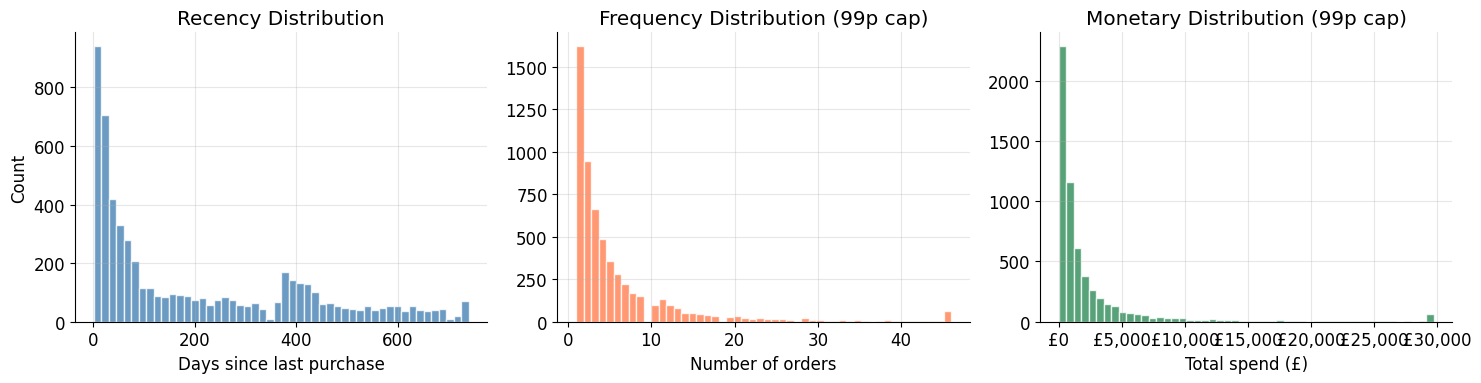

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Recency
axes[0].hist(rfm["Recency"], bins=50, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days since last purchase")
axes[0].set_ylabel("Count")

# Frequency (99th percentile cap)
freq_cap = rfm["Frequency"].quantile(0.99)
axes[1].hist(rfm["Frequency"].clip(upper=freq_cap), bins=50, color="coral", alpha=0.8, edgecolor="white")
axes[1].set_title("Frequency Distribution (99p cap)")
axes[1].set_xlabel("Number of orders")

# Monetary (99th percentile cap)
mon_cap = rfm["Monetary"].quantile(0.99)
axes[2].hist(rfm["Monetary"].clip(upper=mon_cap), bins=50, color="seagreen", alpha=0.8, edgecolor="white")
axes[2].set_title("Monetary Distribution (99p cap)")
axes[2].set_xlabel("Total spend (£)")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))

plt.tight_layout()
plt.savefig("../outputs/figures/rfm_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. RFM 점수화 (1~5 분위)

각 지표를 5분위로 나눠 점수 부여.  
- Recency는 낮을수록 좋으므로 역순 스코어링

In [5]:
def rfm_score(series: pd.Series, ascending: bool = True) -> pd.Series:
    """
    분위수로 1~5 점수 부여.
    rank(method='first')로 동점 처리 후 qcut → 항상 5개 bin 보장.
    ascending=False이면 역순(Recency: 낮을수록 5점).
    """
    ranked = series.rank(method="first", ascending=ascending)
    return pd.qcut(ranked, q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["R_score"] = rfm_score(rfm["Recency"], ascending=False)   # 낮을수록 5점
rfm["F_score"] = rfm_score(rfm["Frequency"], ascending=True)
rfm["M_score"] = rfm_score(rfm["Monetary"], ascending=True)
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

rfm[["Customer ID", "Recency", "Frequency", "Monetary", "R_score", "F_score", "M_score", "RFM_score"]].head(10)

,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,12346,326,12,77556.46,2,5,5,12
1,12347,2,8,5633.32,5,4,5,14
2,12348,75,5,2019.40,3,4,4,11
3,12349,19,4,4428.69,4,3,5,12
4,12350,310,1,334.40,2,1,2,5
5,12351,375,1,300.93,2,1,2,5
6,12352,36,10,2849.84,4,5,4,13
7,12353,204,2,406.76,2,2,2,6
8,12354,232,1,1079.40,2,1,3,6
9,12355,214,2,947.61,2,2,3,7


## 5. 세그먼트 레이블 부여

RFM 점수 조합으로 비즈니스 의미 있는 세그먼트 정의

In [6]:
def assign_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r >= 3 and f <= 2 and m <= 2:
        return "Promising"
    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    elif r == 1 and f >= 4:
        return "Cant Lose Them"
    elif r <= 2 and f <= 2:
        return "Lost"
    else:
        return "Need Attention"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)

seg_counts = rfm["Segment"].value_counts()
print(seg_counts)
print(f"\n총 세그먼트 수: {rfm['Segment'].nunique()}")

Segment
Lost              1526
Loyal             1409
Champions         1293
At Risk            616
New Customers      440
Need Attention     306
Promising          281
Cant Lose Them       7
Name: count, dtype: int64

총 세그먼트 수: 8


## 6. 세그먼트 시각화

### 6-1. 세그먼트별 고객 수 & 매출 비중

In [7]:
seg_summary = rfm.groupby("Segment").agg(
    customer_count=("Customer ID", "count"),
    total_revenue=("Monetary", "sum"),
    avg_recency=("Recency", "mean"),
    avg_frequency=("Frequency", "mean"),
    avg_monetary=("Monetary", "mean"),
).sort_values("total_revenue", ascending=False).round(1)

seg_summary["revenue_pct"] = (seg_summary["total_revenue"] / seg_summary["total_revenue"].sum() * 100).round(1)
seg_summary["customer_pct"] = (seg_summary["customer_count"] / seg_summary["customer_count"].sum() * 100).round(1)

seg_summary

,customer_count,total_revenue,avg_recency,avg_frequency,avg_monetary,revenue_pct,customer_pct
Segment,,,,,,,
Champions,1293,12096578.4,19.8,17.1,9355.4,68.2,22.0
Loyal,1409,2744497.6,71.2,5.4,1947.8,15.5,24.0
At Risk,616,1549099.1,359.3,5.6,2514.8,8.7,10.5
Lost,1526,668327.7,458.7,1.3,438.0,3.8,26.0
New Customers,440,394217.1,27.9,1.5,895.9,2.2,7.5
Need Attention,306,207114.1,293.6,2.5,676.8,1.2,5.2
Promising,281,81056.9,107.3,1.2,288.5,0.5,4.8
Cant Lose Them,7,2538.3,550.6,5.1,362.6,0.0,0.1


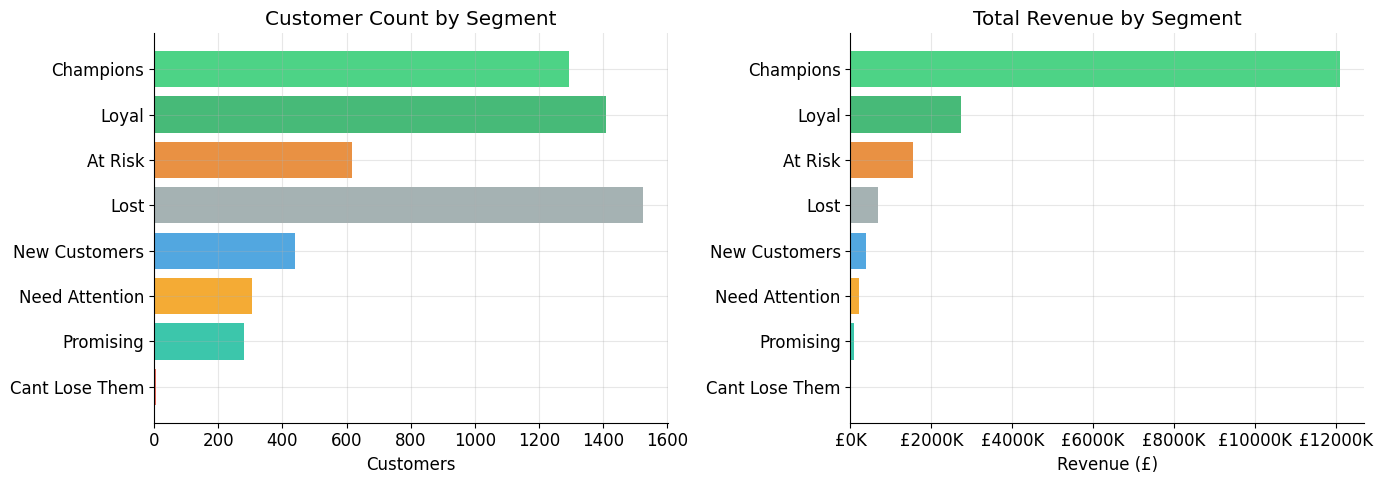

In [8]:
palette = {
    "Champions": "#2ecc71", "Loyal": "#27ae60", "New Customers": "#3498db",
    "Promising": "#1abc9c", "At Risk": "#e67e22", "Cant Lose Them": "#e74c3c",
    "Need Attention": "#f39c12", "Lost": "#95a5a6",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = seg_summary.index.tolist()
colors = [palette.get(s, "gray") for s in order]

# 고객 수
axes[0].barh(order, seg_summary["customer_count"], color=colors, alpha=0.85)
axes[0].set_title("Customer Count by Segment")
axes[0].set_xlabel("Customers")
axes[0].invert_yaxis()

# 매출
axes[1].barh(order, seg_summary["total_revenue"], color=colors, alpha=0.85)
axes[1].set_title("Total Revenue by Segment")
axes[1].set_xlabel("Revenue (£)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}K"))
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../outputs/figures/segment_overview.png", dpi=150, bbox_inches="tight")
plt.show()

### 6-2. RFM 스코어 히트맵 (R vs F, 색=Monetary)

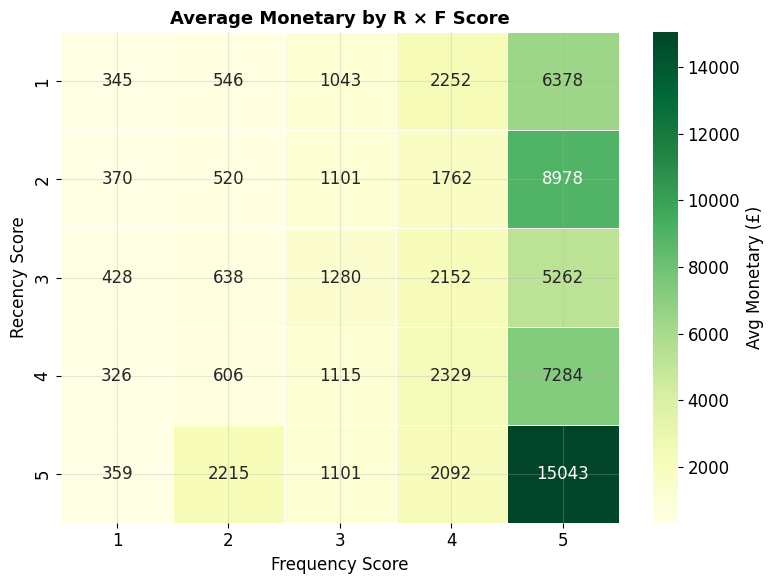

In [9]:
heatmap_data = rfm.groupby(["R_score", "F_score"])["Monetary"].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGn",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Avg Monetary (£)"})
ax.set_title("Average Monetary by R × F Score", fontsize=13, fontweight="bold")
ax.set_xlabel("Frequency Score")
ax.set_ylabel("Recency Score")
plt.tight_layout()
plt.savefig("../outputs/figures/rfm_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 이탈 레이블 생성

다음 노트북의 분류 모델을 위해 이탈 여부 레이블(`Churned`) 정의.  
- 기준: **Recency > 90일** (3개월 이상 구매 없음 = 이탈로 간주)

In [10]:
CHURN_THRESHOLD = 90  # days

rfm["Churned"] = (rfm["Recency"] > CHURN_THRESHOLD).astype(int)

churn_rate = rfm["Churned"].mean() * 100
print(f"이탈 기준: Recency > {CHURN_THRESHOLD}일")
print(f"이탈 고객: {rfm['Churned'].sum():,}명 / {len(rfm):,}명 ({churn_rate:.1f}%)")
print(f"잔류 고객: {(rfm['Churned'] == 0).sum():,}명 ({100 - churn_rate:.1f}%)")

이탈 기준: Recency > 90일
이탈 고객: 2,989명 / 5,878명 (50.9%)
잔류 고객: 2,889명 (49.1%)


## 8. RFM 테이블 저장

In [11]:
import pyarrow as pa

# pyarrow 23.x 버그: 동일 커널에서 to_parquet 재실행 시 pandas.period 중복 등록 에러
try:
    pa.unregister_extension_type("pandas.period")
except Exception:
    pass

rfm.to_parquet(RFM_PATH, index=False)
print(f"Saved → {RFM_PATH}")
print(f"Columns: {rfm.columns.tolist()}")
rfm.head()

Saved → ../data/processed/rfm.parquet
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'RFM_score', 'Segment', 'Churned']


,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment,Churned
0,12346,326,12,77556.46,2,5,5,12,At Risk,1
1,12347,2,8,5633.32,5,4,5,14,Champions,0
2,12348,75,5,2019.40,3,4,4,11,Loyal,0
3,12349,19,4,4428.69,4,3,5,12,Loyal,0
4,12350,310,1,334.40,2,1,2,5,Lost,1
